# Contour Integration: Stress-Testing the Residue Theorem

The residue theorem says

$$\oint_C f(z)\,dz = 2\pi i \sum_k n(C, p_k)\,\mathrm{Res}_{p_k} f .$$

The left side is a line integral: parametrize the path, call a quadrature routine.
The right side is algebra: find the poles, take residues, count windings. The claim
is that two procedures with nothing in common must produce the same number.

This notebook pretends not to believe it, and tries to break it.

**The one thing the two sides share is the definition of $f$** — a single sympy
expression, turned into a numerical callable by `lambdify` for the left side and
differentiated symbolically for the right. What is *not* shared is how the answer
is obtained. `residues.py` never imports numpy; `contour.py` never imports sympy.

In particular the winding number is computed geometrically, by accumulating
$\arg(z(t)-p)$ along the path — **not** from $\frac{1}{2\pi i}\oint\frac{dz}{z-p}$,
which would drag the quadrature routine into the right-hand side and make the
agreement a tautology.

## 1. Setup

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from contour import circle, ellipse, blob, rectangle, trapezoid, predicted_rate
from residues import z, residue_table
from verify import verify, PoleOnContour

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

### CHECK 0 — the right-hand side, on paper

$e^z/z^3$ has a triple pole at the origin. By hand,

$$\mathrm{Res}_0 = \frac{1}{2!}\left.\frac{d^2}{dz^2}e^z\right|_{0} = \frac12,$$

so the integral around any contour winding once about the origin is $\pi i$.
`residue_table` computes this by writing out that formula, and separately checks
it against `sympy.residue`; it raises if the two disagree.

In [2]:
for info in residue_table(sp.exp(z) / z**3):
    print(f"pole {info.location}   order {info.order}   residue {info.residue}")

pole 0   order 3   residue 1/2


## 2. The test matrix

Five cases where the answer is known in closed form. The `turns = -1` row is there
because a test whose expected value is $0$ would survive a global sign error.

In [3]:
matrix = [
    (1/z,              circle(0, 1),           2j*np.pi,  "2*pi*i"),
    (1/(z**2 + 1),     circle(1j, 0.5),        np.pi+0j,  "pi"),
    (sp.exp(z)/z**3,   circle(0, 1),           1j*np.pi,  "pi*i"),
    (1/(z**2 + 1),     circle(0, 2),           0j,        "0  (residues cancel)"),
    (1/z,              circle(0, 1, turns=3),  6j*np.pi,  "6*pi*i"),
    (1/z,              circle(0, 1, turns=-1), -2j*np.pi, "-2*pi*i"),
]

print(f"{'f(z)':18s}{'contour':30s}{'expected':22s}{'|LHS-RHS|':>12s}")
for expr, path, expected, name in matrix:
    r = verify(expr, path)
    assert abs(r.rhs - expected) < 1e-12 and r.abs_error < 1e-12
    print(f"{str(expr):18s}{path.label:30s}{name:22s}{r.abs_error:12.2e}")

f(z)              contour                       expected                 |LHS-RHS|


1/z               circle(c=0j, R=1.0, turns=1)  2*pi*i                    1.03e-17


1/(z**2 + 1)      circle(c=1j, R=0.5, turns=1)  pi                        4.47e-16
exp(z)/z**3       circle(c=0j, R=1.0, turns=1)  pi*i                      2.13e-16
1/(z**2 + 1)      circle(c=0j, R=2.0, turns=1)  0  (residues cancel)      8.49e-17
1/z               circle(c=0j, R=1.0, turns=3)  6*pi*i                    5.65e-17
1/z               circle(c=0j, R=1.0, turns=-1) -2*pi*i                   1.03e-17


## 3. Deformation invariance

This is the sharpest form of the claim. Take $f(z)=\dfrac{1}{z(z-2)}$ and four paths
that all enclose $z=0$ and exclude $z=2$: a circle, an ellipse, a five-lobed star,
and a rectangle.

The left-hand side depends explicitly on the shape — different parametrization,
different sample points, and for the rectangle a different quadrature rule
(the corners destroy the trapezoid rule's periodicity, so it is integrated panel
by panel with Gauss–Legendre). The right-hand side does not know what the path
looks like; it only knows that it winds once.

In [4]:
expr = 1/(z*(z - 2))
paths = [circle(0, 1), ellipse(0, 1.5, 0.7), blob(0, 1, 0.3, 5), rectangle(0, 2.4, 1.6)]
reports = [verify(expr, p) for p in paths]

print(f"{'contour':30s}{'rule':16s}{'n':>6s}{'LHS (imag part)':>22s}{'|LHS-RHS|':>12s}")
for p, r in zip(paths, reports):
    print(f"{p.label:30s}{r.method:16s}{r.n_used:6d}{r.lhs.imag:22.15f}{r.abs_error:12.2e}")
print(f"\nRHS (same for all four): {reports[0].rhs!r}   =  -pi*i")

contour                       rule                 n       LHS (imag part)   |LHS-RHS|
circle(c=0j, R=1.0, turns=1)  trapezoid          256    -3.141592653589793    4.53e-16
ellipse(a=1.5, b=0.7)         trapezoid          256    -3.141592653589793    0.00e+00
blob(R=1.0, amp=0.3, mode=5)  trapezoid          512    -3.141592653589793    0.00e+00
rectangle(w=2.4, h=1.6)       gauss-legendre     128    -3.141592653589773    2.00e-14

RHS (same for all four): (-0-3.141592653589793j)   =  -pi*i


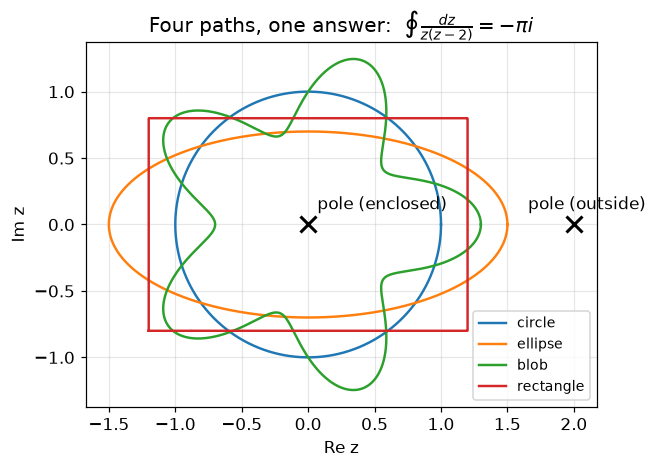

In [5]:
fig, ax = plt.subplots(figsize=(6, 5.4))
t = np.linspace(0, 2*np.pi, 2000)
for p in paths:
    w = p.z(t)
    ax.plot(w.real, w.imag, lw=1.6, label=p.label.split("(")[0])
ax.plot([0, 2], [0, 0], "kx", ms=10, mew=2)
ax.annotate("pole (enclosed)", (0, 0), textcoords="offset points", xytext=(6, 10))
ax.annotate("pole (outside)", (2, 0), textcoords="offset points", xytext=(-30, 10))
ax.set_aspect("equal"); ax.grid(alpha=.3)
ax.set_xlabel("Re z"); ax.set_ylabel("Im z")
ax.set_title(r"Four paths, one answer:  $\oint \frac{dz}{z(z-2)} = -\pi i$")
ax.legend(loc="lower right", fontsize=9)
plt.show()

### CHECK 1 — four different machines, one number

All four agree with $-\pi i$ and with each other to better than $10^{-12}$, while
the rule and the node count differ between rows. That the numbers agree is the
theorem; that the machinery differs is what makes the agreement evidence.

In [6]:
values = [r.lhs for r in reports]
spread = max(abs(a - b) for a in values for b in values)
print(f"spread across the four contours: {spread:.2e}")
print(f"rules used: {sorted({r.method for r in reports})}")
assert spread < 1e-12

spread across the four contours: 2.00e-14
rules used: ['gauss-legendre', 'trapezoid']


## 4. How fast does the left side converge?

On a smooth closed path the integrand $g(t)=f(z(t))\,z'(t)$ is analytic and
$2\pi$-periodic, and the trapezoid rule is then **geometrically** convergent, not
$O(h^2)$. The rate is set by the width of the strip of analyticity: writing
$t=s+i\sigma$, the line $\mathrm{Im}\,t=-\sigma$ maps to the circle of radius
$Re^{-\sigma}$, so a pole at distance $d$ from the centre is met at
$|\mathrm{Im}\,t| = |\ln(d/R)|$. Hence

$$|I_n - I| \sim e^{-an}, \qquad a = \min_k\left|\ln\frac{d_k}{R}\right| .$$

For $f=1/(z-1)$ on $|z|=R$ we can do better than the rate and predict the value
exactly. Expanding $g(t)= i\sum_{m\ge0}R^{-m}e^{-imt}$, the trapezoid rule aliases
precisely the modes that are multiples of $n$, so

$$|I_n - 2\pi i| \;=\; 2\pi\,\frac{R^{-n}}{1-R^{-n}} .$$

The dashed curves below are that formula — computed before the integrator ran,
not fitted to it.

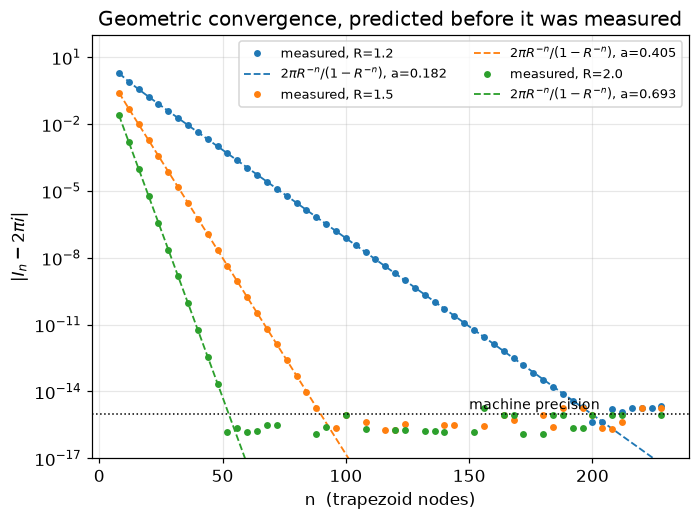

In [7]:
f = lambda w: 1/(w - 1)
ns = np.arange(8, 230, 4)

fig, ax = plt.subplots(figsize=(7, 5))
for R, colour in zip((1.2, 1.5, 2.0), ("C0", "C1", "C2")):
    err = [abs(trapezoid(f, circle(0, R), n) - 2j*np.pi) for n in ns]
    x = R**-ns.astype(float)
    ax.semilogy(ns, err, "o", ms=3.5, color=colour, label=f"measured, R={R}")
    ax.semilogy(ns, 2*np.pi*x/(1 - x), "--", color=colour, lw=1.2,
                label=f"$2\\pi R^{{-n}}/(1-R^{{-n}})$, a={predicted_rate(circle(0,R),[1]):.3f}")
ax.axhline(1e-15, color="k", ls=":", lw=1)
ax.text(150, 1.6e-15, "machine precision", fontsize=9)
ax.set_xlabel("n  (trapezoid nodes)"); ax.set_ylabel(r"$|I_n - 2\pi i|$")
ax.set_title("Geometric convergence, predicted before it was measured")
ax.set_ylim(1e-17, 1e2); ax.grid(alpha=.3); ax.legend(fontsize=8.5, ncol=2)
plt.show()

### CHECK 2 — the prediction is a value, not a trend

Ratio of measured error to the closed-form prediction, over the range where the
error is above the roundoff floor. Anything other than $1$ means the analysis is
wrong.

In [8]:
for R in (1.2, 1.5, 2.0):
    ratios = []
    for n in ns:
        e = abs(trapezoid(f, circle(0, R), n) - 2j*np.pi)
        if e < 1e-13:
            continue
        x = float(R)**-int(n)
        ratios.append(e/(2*np.pi*x/(1 - x)))
    print(f"R={R}:  measured/predicted in [{min(ratios):.6f}, {max(ratios):.6f}]"
          f"   over {len(ratios)} values of n")

R=1.2:  measured/predicted in [0.992746, 1.000044]   over 42 values of n
R=1.5:  measured/predicted in [0.999978, 1.000285]   over 18 values of n
R=2.0:  measured/predicted in [0.999692, 1.000003]   over 10 values of n


## 5. Where it breaks

Stress-testing means finding the edge, not only collecting successes. Put a pole
*on* the path — $f=1/(z-1)$ on the unit circle. The theorem says nothing here: the
integral does not exist. `verify` refuses rather than returning a number.

In [9]:
try:
    verify(1/(z - 1), circle(0, 1))
except PoleOnContour as exc:
    print("PoleOnContour:", exc)

PoleOnContour: pole (1+0j) lies on circle(c=0j, R=1.0, turns=1) (distance 0.00e+00)


And the rate formula explains *why* it has to fail: as the pole approaches the
contour, $d\to R$, so $a=|\ln(d/R)|\to 0$ and the geometric convergence collapses.
The cost of a fixed accuracy diverges before the integral does.

In [10]:
print(f"{'d/R':>8s}{'a = |ln(d/R)|':>16s}{'n for 1e-12':>14s}")
for d in (0.5, 0.8, 0.9, 0.95, 0.99, 0.999):
    a = predicted_rate(circle(0, 1), [d])
    print(f"{d:8.3f}{a:16.5f}{np.log(1e12)/a:14.0f}")

     d/R   a = |ln(d/R)|   n for 1e-12
   0.500         0.69315            40
   0.800         0.22314           124
   0.900         0.10536           262
   0.950         0.05129           539
   0.990         0.01005          2749
   0.999         0.00100         27617


## 6. What this is evidence for

Six closed-form cases agree to $10^{-12}$ or better. Four geometrically unrelated
contours — run through two different quadrature rules — give the same number, which
the right-hand side reproduces without ever being told the shape of the path. The
convergence rate was predicted from the pole positions and then observed, value for
value rather than as a trend. And where the theorem's hypotheses fail, the code fails
too, in the way the analysis says it should.

None of that is a proof. But the two computations really do share no machinery, and
they really do agree.

**Not covered here** (see the plan's Tier 2): using the theorem to sum
$\sum n^{-2}=\pi^2/6$ via $\pi\cot(\pi z)/z^2$; the essential singularity $e^{1/z}$,
where the left side does not even notice and only the right side has to work harder;
and the principal-value structure of the divergence above.